In [8]:
import sys
import numpy as np
import scipy.io as io
from pathlib import Path

root_dir = Path.cwd().parent.parent
sys.path.insert(0, str(root_dir))
from docs.plot_setup import set_professional_style
plt = set_professional_style(fontsize=12)

In [9]:
ref_res = io.loadmat('results/monolithic_simple.mat')
cs_res_jacobi = io.loadmat('results/simple_coupled_Jacobi.mat')
cs_res_gs = io.loadmat('results/simple_coupled_Gauss-Seidel.mat')
cs_res_ijcsa = io.loadmat('results/simple_coupled_IJCSA.mat')

In [ ]:
cs_style = {'color': 'tab:blue', 'linestyle': 'None', 'marker': 'o', 'markersize': 4, 'label': 'Co-Simulation (FMUs with CVODE)'}
modelica_style = {'color': 'tab:orange', 'linestyle': 'None', 'marker': 'o', 'markersize': 2, 'label': 'Monolithic (Modelica with DASSL)'}
error_style = {'color': 'tab:red', 'linestyle': 'None', 'linewidth': 2, 'label': 'Error', 'marker': 'x', 'markersize': 4}

common_style = {'linestyle': 'None', 'marker': 'o', 'markersize': 4}
simple_style = {'marker': 'o', 'markersize': 4}
complex_style = {'marker': 's', 'markersize': 2}
ref_simple_style = {'color': 'tab:orange', **common_style, 'label': 'Monolithic (simple)', **simple_style}
ref_complex_style = {'color': 'tab:green', **common_style, 'label': 'Monolithic (complex)', **complex_style}
cs_simple_style = {'color': 'tab:blue', **common_style, 'label': 'Co-Simulation (simple)', **simple_style}
cs_complex_style = {'color': 'tab:red', **common_style, 'label': 'Co-Simulation (complex)', **complex_style}

### 1. Monolithic Simulation Results

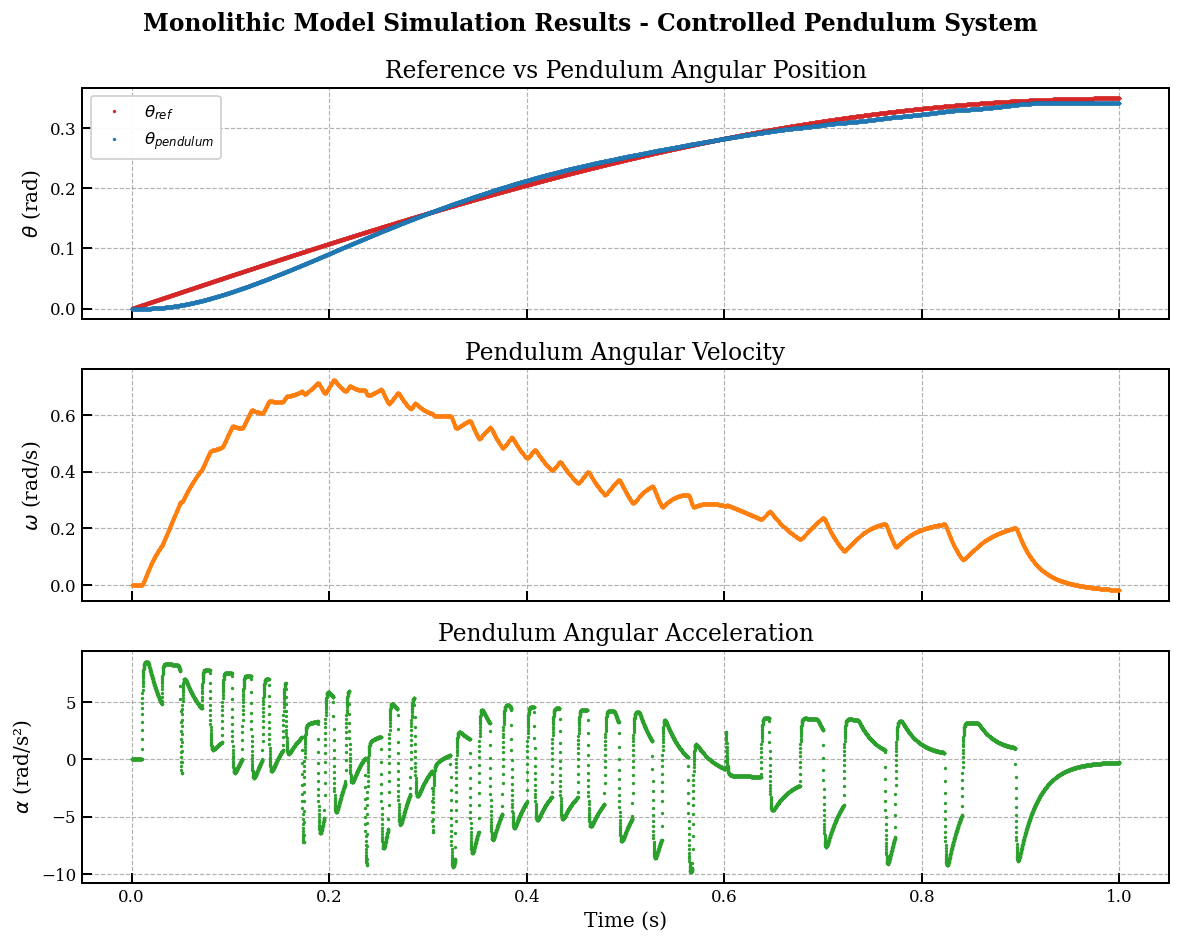

In [32]:
t_vals = ref_res['time'].flatten()
q_ref = ref_res['reference.q_ref'].flatten()
q_pendulum = ref_res['pendulum.q'].flatten()
omega_pendulum = ref_res['pendulum.omega'].flatten()
alpha_pendulum = ref_res['pendulum.alpha'].flatten()

style = {'linestyle': 'None', 'marker': 'o', 'markersize': 1}

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Monolithic Model Simulation Results - Controlled Pendulum System', fontweight='bold', fontsize=14)

axs[0].set_title('Reference vs Pendulum Angular Position')
axs[0].plot(t_vals, q_ref, label=r'$\theta_{ref}$', color='tab:red', **style)
axs[0].plot(t_vals, q_pendulum, label=r'$\theta_{pendulum}$', color='tab:blue', **style)
axs[0].set_ylabel(r'$\theta$ (rad)')
axs[0].legend()
axs[0].grid()

axs[1].set_title('Pendulum Angular Velocity')
axs[1].plot(t_vals, omega_pendulum, label=r'$\omega_{pendulum}$', color='tab:orange', **style)
axs[1].set_ylabel(r'$\omega$ (rad/s)')
axs[1].grid()

axs[2].set_title('Pendulum Angular Acceleration')
axs[2].plot(t_vals, alpha_pendulum, label=r'$\alpha_{pendulum}$', color='tab:green', **style)
axs[2].set_ylabel(r'$\alpha$ (rad/s²)')
axs[2].set_xlabel('Time (s)')
axs[2].grid()

plt.tight_layout()
plt.show()

### 2. Co-Simulation Results - Algorithm Comparison

In [33]:
monolithic_style = {'color': 'tab:red', 'linestyle': 'None', 'marker': 'o', 'markersize': 4, 'label': 'Monolithic'}
jacobi_style = {'color': 'tab:blue', 'linestyle': 'None', 'marker': 'o', 'markersize': 4, 'label': 'Jacobi'}
gs_style = {'color': 'tab:orange', 'linestyle': 'None', 'marker': 's', 'markersize': 4, 'label': 'Gauss-Seidel'}
ijcsa_style = {'color': 'tab:green', 'linestyle': 'None', 'marker': '^', 'markersize': 4, 'label': 'IJCSA'}

#### 2.1 Reference

In [45]:
ref_time = ref_res['time'].flatten()
ref_vals = ref_res['pendulum.q'].flatten()

jacobi_res = cs_res_jacobi['0.020']['pendulum'].flatten()


jacobi_res =jacobi_res.flatten()
jacobi_res[0][0][0][0]

array([[array([[0]]), array([[0.]])],
       [array([[0.02]]), array([[0.]])],
       [array([[0.04]]), array([[0.]])],
       [array([[0.06]]), array([[0.]])],
       [array([[0.08]]), array([[0.]])],
       [array([[0.1]]), array([[4.90115142]])],
       [array([[0.12]]), array([[7.62502948]])],
       [array([[0.14]]), array([[8.2842331]])],
       [array([[0.16]]), array([[7.94780675]])],
       [array([[0.18]]), array([[7.54492459]])],
       [array([[0.2]]), array([[7.10098568]])],
       [array([[0.22]]), array([[6.62053274]])],
       [array([[0.24]]), array([[6.10792789]])],
       [array([[0.26]]), array([[5.56762077]])],
       [array([[0.28]]), array([[5.00438086]])],
       [array([[0.3]]), array([[4.42303686]])],
       [array([[0.32]]), array([[3.82859699]])],
       [array([[0.34]]), array([[3.22613298]])],
       [array([[0.36]]), array([[-7.69680065]])],
       [array([[0.38]]), array([[-4.87525719]])],
       [array([[0.4]]), array([[-9.75870176]])],
       [array([[

#### 2.2 Reference Sensor

#### 2.3 Pendulum Sensor

#### 2.4 PID Controller

#### 2.5 Drive

#### 2.6 Pendulum

In [22]:
cs_style = {'color': 'tab:blue', 'linestyle': 'None', 'marker': 'o', 'markersize': 4, 'label': 'Co-Simulation (FMUs with CVODE)'}
modelica_style = {'color': 'tab:orange', 'linestyle': 'None', 'marker': 'o', 'markersize': 2, 'label': 'Monolithic (Modelica with DASSL)'}
error_style = {'color': 'tab:red', 'linestyle': '-', 'linewidth': 2, 'label': 'Error'}

t_vals_cs, q_ref_cs = zip(*ref.outputs['q_ref'].history)
t_vals_cs = np.array(t_vals_cs)
q_ref_cs = np.array(q_ref_cs)

t_vals_ref = np.array(results['time'])
q_ref_vals_ref = np.array(results['reference.q_ref'])
q_ref_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, q_ref_vals_ref)

denom = np.max(np.abs(q_ref_vals_ref_interp))
q_ref_error = (q_ref_cs - q_ref_vals_ref_interp) / denom

max_error = np.max(np.abs(q_ref_error))
print(f"Maximum relative error in q_ref: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, q_ref_cs, **cs_style)
plt.plot(t_vals_ref, q_ref_vals_ref, **modelica_style)
plt.xlabel('Time $(s)$')
plt.ylabel('Reference Angle $q_{ref}$ (rad)')
plt.title('Reference Angle $q_{ref}$')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'ref' is not defined

Maximum absolute error in Uq_ref: 0.000e+00


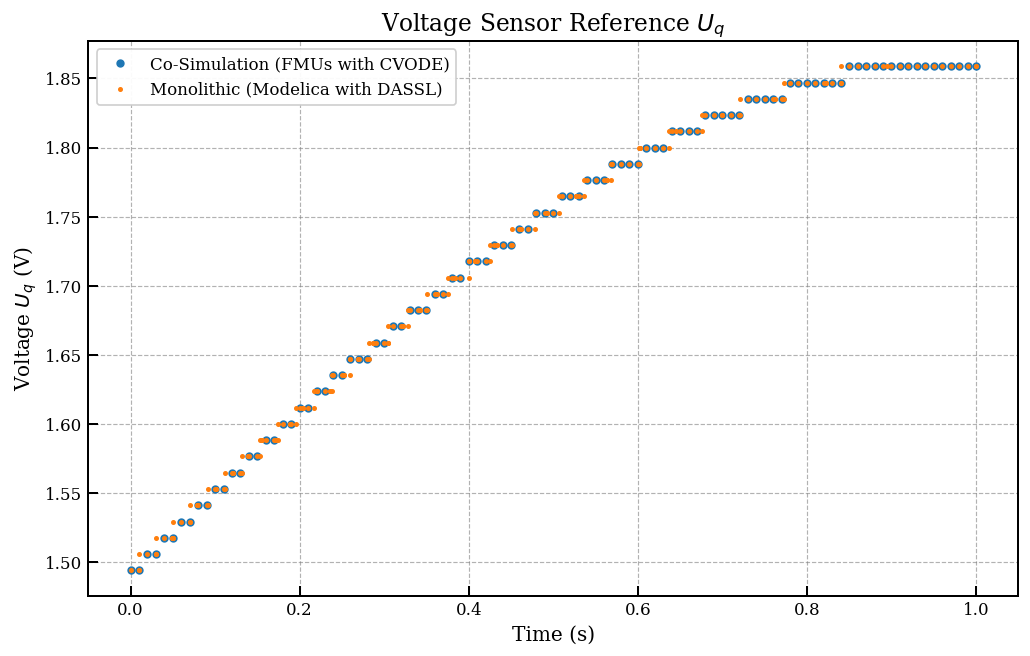

In [93]:
# Sensor Ref Uq
t_vals_cs, Uq_ref_cs = zip(*sensor_ref.outputs['U_q'].history)
t_vals_cs = np.array(t_vals_cs)
Uq_ref_cs = np.array([val.magnitude for val in Uq_ref_cs])

t_vals_ref = np.array(results['time'])
Uq_ref_ref = np.array(results['sensor_ref.U_q'])

Uq_ref_ref_interp = np.interp(t_vals_cs, t_vals_ref, Uq_ref_ref)
Uq_ref_error = Uq_ref_cs - Uq_ref_ref_interp
max_error = np.max(np.abs(Uq_ref_error))
print(f"Maximum absolute error in Uq_ref: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, Uq_ref_cs, **cs_style)
plt.plot(t_vals_ref, Uq_ref_ref, **modelica_style)
plt.xlabel('Time (s)')
plt.ylabel('Voltage $U_{q}$ (V)')
plt.title('Voltage Sensor Reference $U_{q}$')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in Uq_state: 6.329e-03


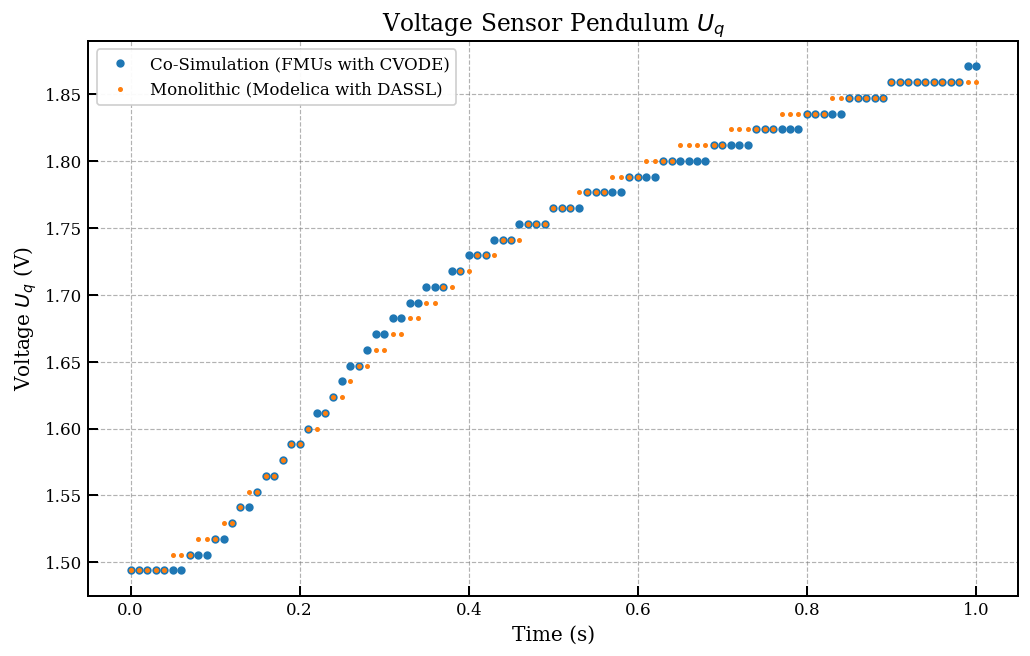

In [94]:
# Sensor State Uq
t_vals_cs, Uq_state_cs = zip(*sensor_state.outputs['U_q'].history)
t_vals_cs = np.array(t_vals_cs)

Uq_state_cs = np.array([val.magnitude for val in Uq_state_cs])
t_vals_ref = np.array(results['time'])

Uq_state_vals_ref = np.array(results['sensor_state.U_q'])
Uq_state_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, Uq_state_vals_ref)
denom = np.max(np.abs(Uq_state_vals_ref_interp))
Uq_state_error = (Uq_state_cs - Uq_state_vals_ref_interp) / denom
max_error = np.max(np.abs(Uq_state_error))
print(f"Maximum relative error in Uq_state: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, Uq_state_cs, **cs_style)
plt.plot(t_vals_cs, Uq_state_vals_ref_interp, **modelica_style)
plt.xlabel('Time (s)')
plt.ylabel('Voltage $U_{q}$ (V)')
plt.title('Voltage Sensor Pendulum $U_{q}$')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in u_pid: 1.247e+00


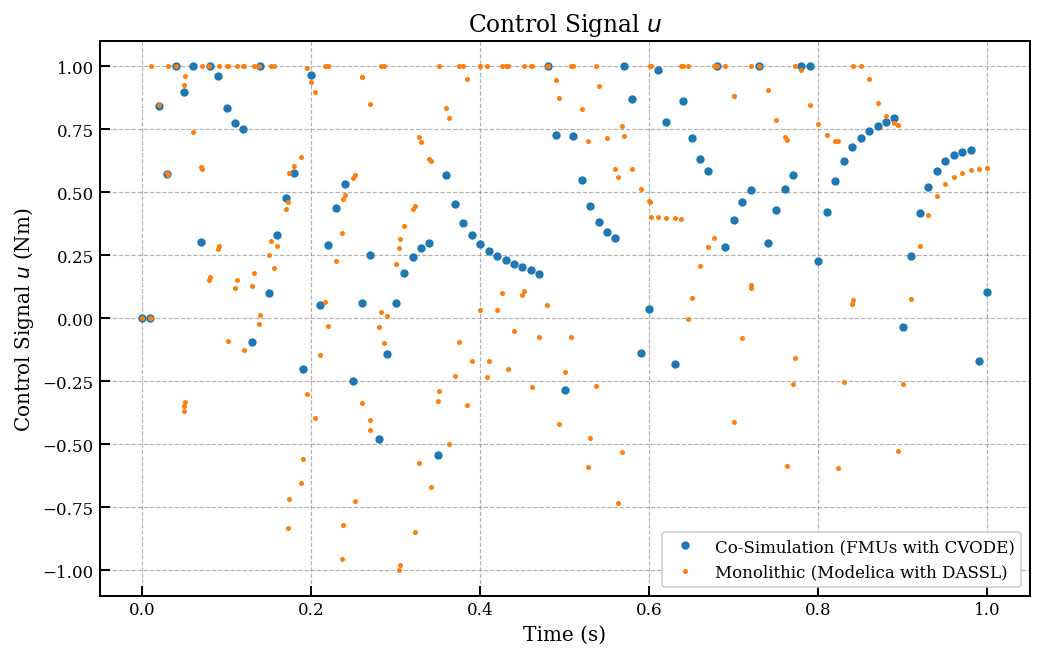

In [95]:
# PID u
t_vals_cs, u_pid_cs = zip(*pid.outputs['u'].history)
t_vals_cs = np.array(t_vals_cs)
u_pid_cs = np.array(u_pid_cs)

t_vals_ref = np.array(results['time'])
u_pid_vals_ref = np.array(results['pid.u'])
u_pid_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, u_pid_vals_ref)

denom = np.max(np.abs(u_pid_vals_ref_interp))
u_pid_error = (u_pid_cs - u_pid_vals_ref_interp) / denom

max_error = np.max(np.abs(u_pid_error))
print(f"Maximum relative error in u_pid: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, u_pid_cs, **cs_style)
plt.plot(t_vals_ref, u_pid_vals_ref, **modelica_style)
plt.xlabel('Time (s)')
plt.ylabel('Control Signal $u$ (Nm)')
plt.title('Control Signal $u$')
plt.legend()
plt.grid(True)
plt.show()

Maximum relative error in torque_drive: 9.361e-01


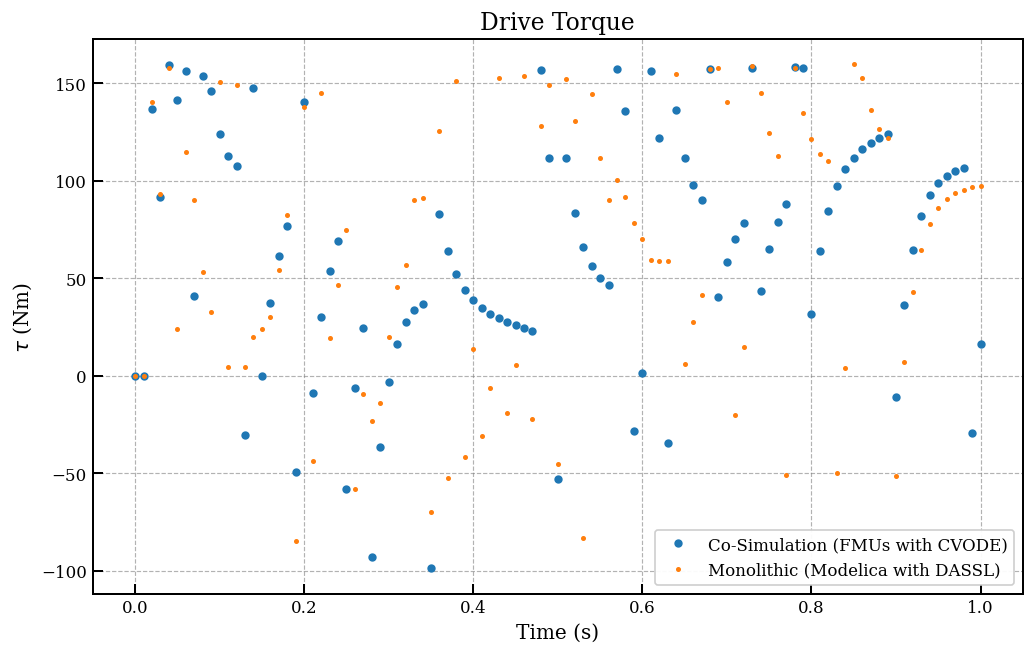

In [96]:
# Drive torque
t_vals_cs, torque_drive_cs = zip(*drive.outputs['torque'].history)
t_vals_cs = np.array(t_vals_cs)
torque_drive_cs = np.array([val.magnitude for val in torque_drive_cs])

t_vals_ref = np.array(results['time'])
torque_drive_vals_ref = np.array(results['drive.torque'])
torque_drive_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, torque_drive_vals_ref)
denom = np.max(np.abs(torque_drive_vals_ref_interp))
torque_drive_error = (torque_drive_cs - torque_drive_vals_ref_interp) / denom

max_error = np.max(np.abs(torque_drive_error))
print(f"Maximum relative error in torque_drive: {max_error:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(t_vals_cs, torque_drive_cs, **cs_style)
plt.plot(t_vals_cs, torque_drive_vals_ref_interp, **modelica_style)
plt.xlabel('Time (s)')
plt.ylabel(r'$\tau$ (Nm)')
plt.title('Drive Torque')
plt.legend()
plt.grid(True)
plt.show()

RMSE: 5.175e-03


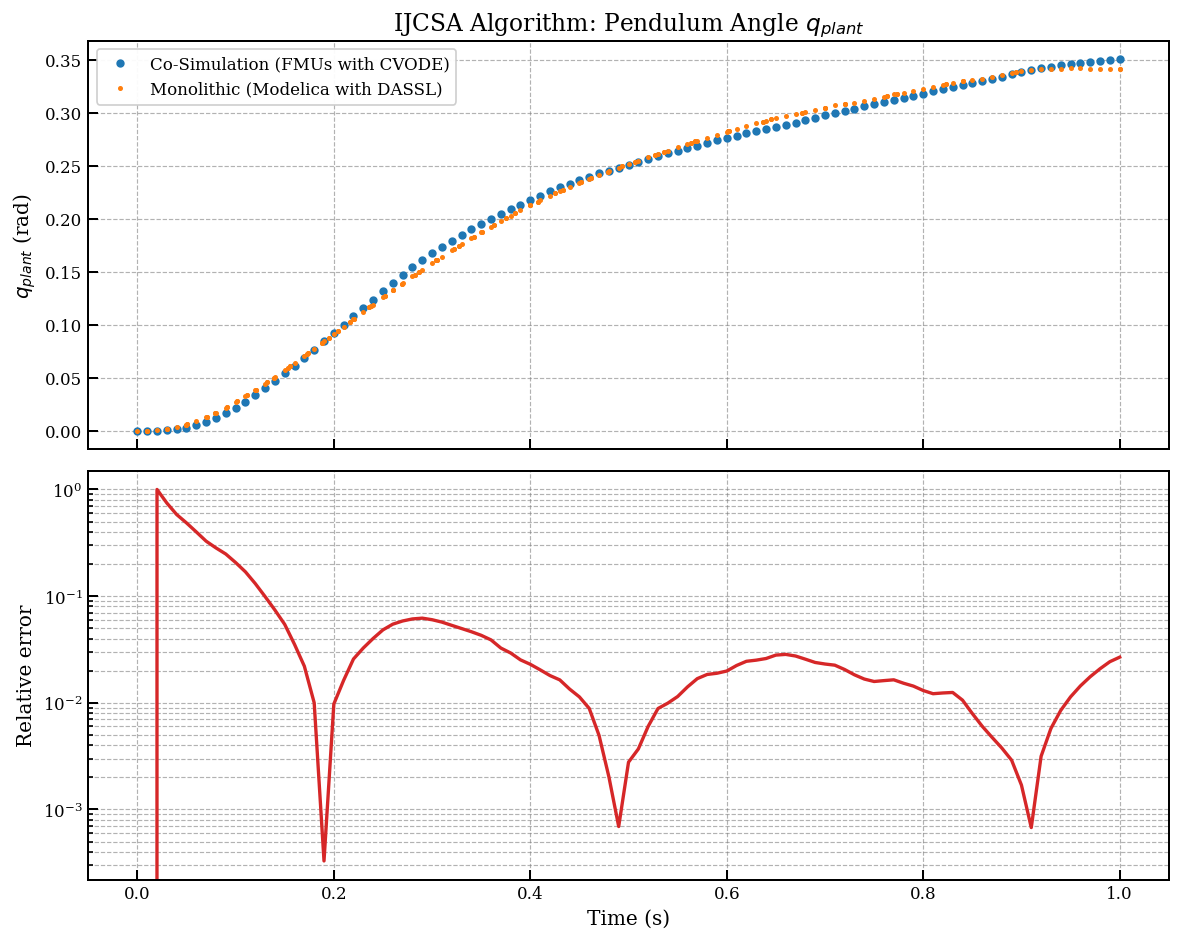

In [97]:
# Pendulum q
t_vals_cs, q_state_cs = zip(*pendulum.outputs['q'].history)
t_vals_cs = np.array(t_vals_cs)
q_state_cs = np.array([val.magnitude for val in q_state_cs])

t_vals_ref = np.array(results['time'])
q_state_vals_ref = np.array(results['pendulum.q'])
q_state_vals_ref_interp = np.interp(t_vals_cs, t_vals_ref, q_state_vals_ref)

# Errors
abs_error = np.abs(q_state_cs - q_state_vals_ref_interp)

eps = 1e-8
denom = np.maximum(np.abs(q_state_vals_ref_interp), eps)
rel_error = abs_error / denom

# summary metrics
max_abs = np.max(abs_error)
rmse = np.sqrt(np.mean((q_state_cs - q_state_vals_ref_interp)**2))
max_rel = np.max(rel_error)

print(f"RMSE: {rmse:.3e}")

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t_vals_cs, q_state_cs, **cs_style)
axs[0].plot(t_vals_ref, q_state_vals_ref, **modelica_style)
axs[0].set_ylabel(r'$q_{plant}$ (rad)')
axs[0].set_title(f'{mode} Algorithm: Pendulum Angle $q_{{plant}}$')
axs[0].legend()
axs[0].grid(True)

axs[1].semilogy(t_vals_cs, rel_error, **error_style)
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Relative error')
axs[1].grid(which='both')

plt.tight_layout()
plt.savefig(f"figures/cs_alg_verificationq_state_complex_{mode}.svg")
plt.show()
